<a href="https://colab.research.google.com/github/kalex066/ML-MedicalCostPersonal/blob/main/MedicalCostPersonal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Medical Cost Personal Prediction**

**Objetivo:** Implementar un pipeline completo de machine learning para un problema de clasificacion, enfocándose en el preprocesamiento robusto de datos, la gestión de variables categóricas y la optimización de hiperparámetros mediante técnicas de búsqueda sistemática (GridSearchCV y RandomizedSearchCV).Aplicar conceptos de codificación de variables (encoding), escalamiento de características (feature scaling), manejo de outliers y comparación de rendimiento entre modelos optimizados.

**Dataset:** https://www.kaggle.com/datasets/mirichoi0218/insurance

**Descripción del Dataset:** Este conjunto de datos proporciona información detallada sobre los costos cobrados por el seguro médico, permitiendo analizar como diferentes factores sociodemográficos y de salud influyen en el gasto sanitario final.

|**Columna**|**Descripción**|
|:---|:---|
|age|Edad del beneficiario principal (años)|
|sex|Género del beneficiario (female/male)|
|bmi|Índice de masa corporal (estructura corporal del paciente|
|children|Número de hijos cubiertos por el seguro / dependientes|
|smoker|Indicador de si el beneficiario fuma o no (yes/no)|
|region|Zona residencial del beneficiario en EE. UU. (northeast, southeast, southwest, northwest)|
|charges|Costos médicos individuales facturados por el seguro|


**Target de clasificación:** `smoker` → binario (1 = fumador, 0 = no fumador)

**Pregunta del Negocio:** ¿Puede la aseguradora detectar si un cliente es fumador a partir de sus datos médicos y costos históricos, sin que el cliente lo declare explícitamente?"

# <font color='1890A3'>**SECCION 1. CARGA Y PRIMERA EXPLORACION**
**Cargar el dataset | head | tail | info | describe | shape** </font>

>## <font color='1890A3'>**Paso 1.1 Configuracion e importaciones** </font>

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns
import warnings
import math
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import (train_test_split, GridSearchCV, RandomizedSearchCV,
                                     cross_val_score, StratifiedKFold)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from scipy.stats import randint, uniform
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay,
                             confusion_matrix, classification_report)

warnings.filterwarnings('ignore')

# Configuración de estilos
plt.rcParams.update({
    'figure.facecolor': '#0F0F1A', 'axes.facecolor': '#1A1A2E',
    'axes.edgecolor': '#444',      'axes.labelcolor': '#CCC',
    'xtick.color': '#AAA',         'ytick.color': '#AAA',
    'text.color': 'white',         'grid.color': '#333',
    'grid.linestyle': '--',        'legend.facecolor': '#1A1A2E',
    'legend.edgecolor': '#444',
})

template = dict(
    layout=dict(
        paper_bgcolor='#0F0F1A',
        plot_bgcolor='#1A1A2E',
        font=dict(color='white'),
        xaxis=dict(gridcolor='#333'),
        yaxis=dict(gridcolor='#333')
    )
)

# Paleta de colores para gráficos posteriores
PURPLE = '#6C3CE1'
TEAL   = '#00C9A7'
AMBER  = '#F59E0B'
RED    = '#E44D26'
BLUE   = '#3B82F6'
PINK   = '#EC4899'

> ## <font color='1890A3'>**Paso 1.2 Cargar el dataset**</font>

In [2]:
df = pd.read_csv('/content/sample_data/insurance.csv')

print(f'Dataset cargado exitosamente!')
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Memoria aproximada: {df.memory_usage(deep=True).sum() / 1024:.0f} KB')
print(f'\nColumnas: {list(df.columns)}')

Dataset cargado exitosamente!
Dimensiones: 1338 filas x 7 columnas
Memoria aproximada: 255 KB

Columnas: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


> ## <font color='1890A3'>**Paso 1.3 Primeras y Ultimas filas del Dataset**</font>

In [3]:
print('=== Primeras 5 filas ===')
display(df.head())
print('\n=== Ultimas 5 filas ===')
display(df.tail())

=== Primeras 5 filas ===


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



=== Ultimas 5 filas ===


,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


> ## <font color='1890A3'>**Paso 1.4 Estructura General del Dataset**</font>

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


El dataset tienen 7 columnas y 1338 filas, aparentemente sin valores nulos.
4 columnas numericas y 3 categoricas.

> ## <font color='1890A3'>**Paso 1.5 Estadisticas Descriptivas del Dataset**</font>

In [5]:
df.describe()
print('=== Columnas numericas ===')
display(df.describe())
print('\n=== Columnas categoricas ===')
display(df.describe(include='object'))

=== Columnas numericas ===


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010



=== Columnas categoricas ===


,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


**Variables Numéricas**
Chargues tiene una **media superior a la mediana**(13 270 > 9 382), lo que indica que su distribución tiene sesgo a la derecha (muchos costos bajos y unos pocos extremadamente altos).

El rango de las edades esta entre 18 y 64 años, con distribución bastante uniforme.

El indice de masa corporal, con media de 30.6, lo cual es un valor alto considerando que un IMC > 30 se clasifica generalmente como obesidad.

El numero de hijos tiene un rango de 0 a 5, con una media de 1. Muchos registros tienen 0 hijos.

**Variables Categóricas**

La variable smoker esta desbalanceada, 1 064 personas son "no fumadoras" de un total de 1 338. Esto significa que el modelo tendrá pocos datos de fumadores para aprender.

La variable region se ve bien distribuida con Southeast como el valor mas frecuente con 364, por lo que no parece haber un desbalance en esta variable.

La variable sexo tambien balanceada, 676 hombres vs 662 mujeres.

# <font color='1890A3'>**SECCION 2. LIMPIEZA DE DATOS**
**tipos | duplicados | inconsistencias | nulos | outliers** </font>

> ## <font color='1890A3'>**Paso 2.1 Verificar y corregir tipos de datos**</font>

In [6]:
print('Tipos de Datos ANTES de limpiar:')
print(df.dtypes)
print()

Tipos de Datos ANTES de limpiar:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object



> ## <font color='1890A3'>**Paso 2.2 Identificar consistencias en variables categoricas**</font>

In [7]:
print("Valores únicos en sex:", df['sex'].unique())
print("Valores únicos en region:", df['region'].unique())


Valores únicos en sex: ['female' 'male']
Valores únicos en region: ['southwest' 'southeast' 'northwest' 'northeast']


> ## <font color='1890A3'>**Paso 2.3 Identificar y eliminar duplicados**</font>

In [8]:
n_total = len(df)
n_dupes = df.duplicated().sum()

print(f'Filas totales:           {n_total}')
print(f'Duplicados exactos:      {n_dupes} ({n_dupes/n_total*100:.1f}%)')

Filas totales:           1338
Duplicados exactos:      1 (0.1%)


> ## <font color='1890A3'>**Paso 2.4 Analisis de valores nulos**</font>

In [9]:
null_report = pd.DataFrame({
    'Nulos':      df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
}).query('Nulos > 0').sort_values('Porcentaje', ascending=False)

null_report['Umbral'] = null_report['Porcentaje'].apply(
    lambda x: 'Imputar (< 30%)' if x < 30
    else ('Evaluar (30-50%)' if x < 50 else 'Eliminar columna (> 50%)')
)

print('=== Columnas con valores nulos ===')
display(null_report)
print(f"Valores nulos en el dataset: {df.isnull().sum().sum()}")

=== Columnas con valores nulos ===


,Nulos,Porcentaje,Umbral


Valores nulos en el dataset: 0


> ## <font color='#1890A3'>**Paso 2.6 Identificar y Eliminar Outliers** </font>

**Visualizacion de Outliers**

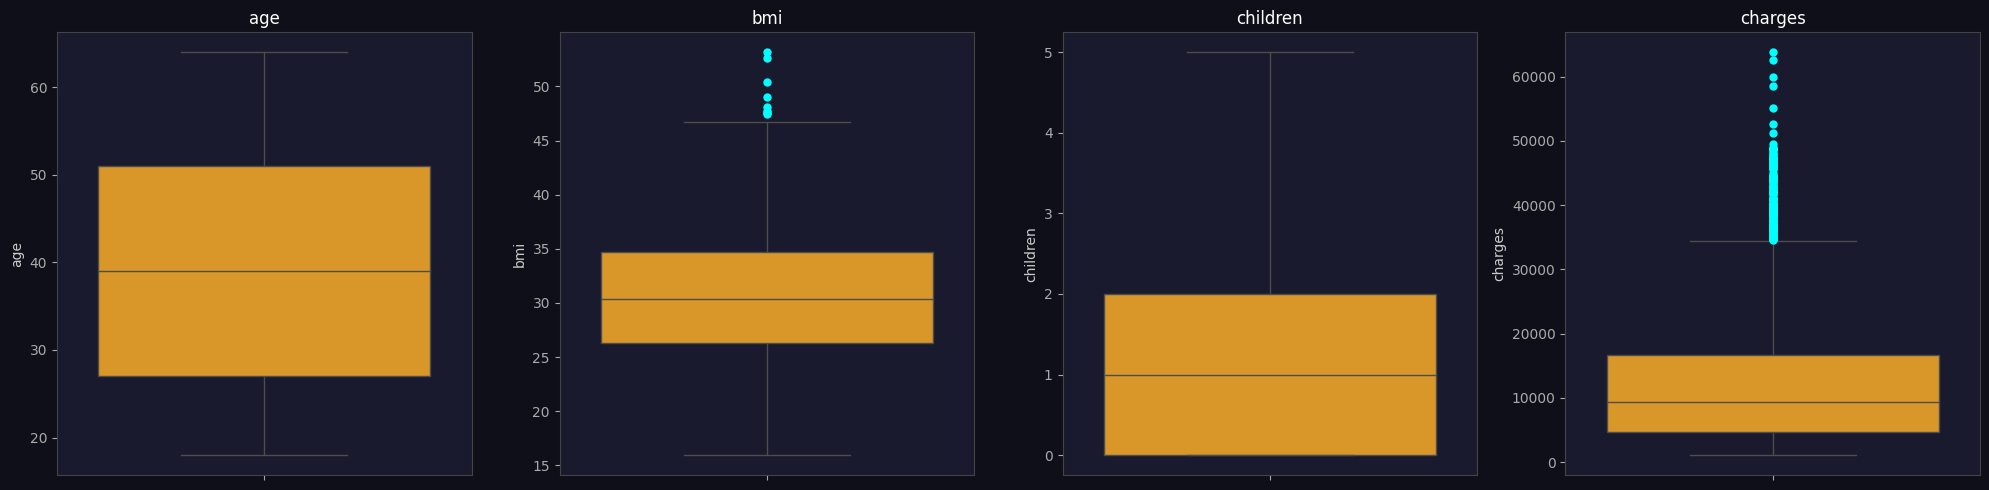

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
columns = ['age', 'bmi', 'children', 'charges']
flierprops = {
    'marker': 'o',
    'markerfacecolor': 'cyan',
    'markeredgecolor': 'cyan',
    'markersize': 5
}
for i, col in enumerate(columns):
    sns.boxplot(y=df[col], ax=axes[i], flierprops=flierprops, color=AMBER)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

>**Analisis**


`age` con distribucion uniforme y centrada alrededor de los 40 años. Sin outliers.

`bmi` la mayoria de los datos se concentran entre 27 y 35, indicando un nivel promedio elevado.Presenta outliers en la parte superior (por encima de 47). ya se habia observado en el describe valores superiores a 30 que es lo considerado como sobrepeso.

`children` con valores concentrados entre 0 y 2, con mediana en uno. La mayoria de las personas tienen pocos hijos.

`charges` La mayoría de los costos estan por debajo de 15 000 usd.
Contiene una cantidad significativa de outliers entre los 35 000 y 60 000 usd.

In [11]:
print('----- ANALISIS DE OUTLIERS (Smoker) -----')
print()

# Valores imposibles
invalidos = df[(df['age'] <= 0) | (df['bmi'] <= 0)]
print(f'Registros con valores físicamente imposibles: {len(invalidos)} filas')

cols_analisis = ['bmi', 'charges']

for col in cols_analisis:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    limite_sup = q3 + 1.5 * iqr

    outliers = df[df[col] > limite_sup]

    print(f'\nVariable: {col}')
    print(f'  Q1={q1:.2f}  Q3={q3:.2f}  IQR={iqr:.2f}  Limite Superior={limite_sup:.2f}')
    print(f'  Registros > limite IQR: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)')

    # Decisión dinámica según la variable
    if col == 'bmi':
        print(f'  Decisión: Valores altos de {col} son indicadores de condiciones reales de salud (sobrepeso).')
        print(f'  Acción: Mantener para preservar la representatividad clínica.')
    elif col == 'charges':
        print(f'  Decisión: Valores altos de {col} representan pacientes con tratamientos complejos o complicaciones médicas.')
        print(f'  Acción: Mantener; eliminar estos valores sesgaría el modelo hacia costos bajos, perdiendo la realidad de casos críticos.')

----- ANALISIS DE OUTLIERS (Smoker) -----

Registros con valores físicamente imposibles: 0 filas

Variable: bmi
  Q1=26.30  Q3=34.69  IQR=8.40  Limite Superior=47.29
  Registros > limite IQR: 9 (0.7%)
  Decisión: Valores altos de bmi son indicadores de condiciones reales de salud (sobrepeso).
  Acción: Mantener para preservar la representatividad clínica.

Variable: charges
  Q1=4740.29  Q3=16639.91  IQR=11899.63  Limite Superior=34489.35
  Registros > limite IQR: 139 (10.4%)
  Decisión: Valores altos de charges representan pacientes con tratamientos complejos o complicaciones médicas.
  Acción: Mantener; eliminar estos valores sesgaría el modelo hacia costos bajos, perdiendo la realidad de casos críticos.


> ## <font color='#1890A3'>**Paso 2.7 Eliminar Columnas Innecesarias** </font>
Ninguna

> ## <font color='#1890A3'>**Paso 2.8 Resumen proceso de Limpieza** </font>

In [12]:
print('------ RESUMEN DEL DATASET LIMPIO ------')
filas_finales, columnas_finales = df.shape
print("---------------------------------------------------------")
print(f"Dimensiones Finales : {filas_finales} filas x {columnas_finales} columnas")
print(f"Valores Nulos Totales: {df.isnull().sum().sum()} (¡Dataset 100% limpio!)")
print("---------------------------------------------------------")
print("Conteo de Variables por Tipo de Dato:")
print(df.dtypes.value_counts())
print("---------------------------------------------------------")

------ RESUMEN DEL DATASET LIMPIO ------
---------------------------------------------------------
Dimensiones Finales : 1338 filas x 7 columnas
Valores Nulos Totales: 0 (¡Dataset 100% limpio!)
---------------------------------------------------------
Conteo de Variables por Tipo de Dato:
object     3
int64      2
float64    2
Name: count, dtype: int64
---------------------------------------------------------


# <font color='#1890A3'> **SECCION 3 EXPLORACION DE DATOS (EDA)**
**Univariante x2 | Multivariante x2 | Interpretacion** </font>

> ## <font color='#1890A3'>**BarPlot de Smoker**</font>

**Objetivo:** Entender la distribucion de la variable objetivo del analisis


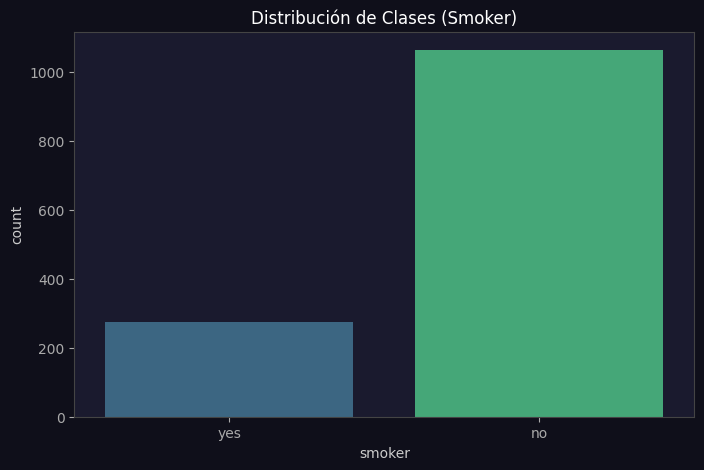

In [13]:
plt.figure(figsize=(8, 5))
sns.countplot(x='smoker', data=df, palette='viridis')
plt.title("Distribución de Clases (Smoker)")
plt.show()

> **Analisis**
Los datos estan desbalanceados, la clase de no fumadores es mucho mayor que la de fumadores.


> ## <font color='#1890A3'>**stacked bar chart de variables categoricas**</font>

**Objetivo:** Comparar la proporción de la variable objetivo (charges_bin) según cada categoría.

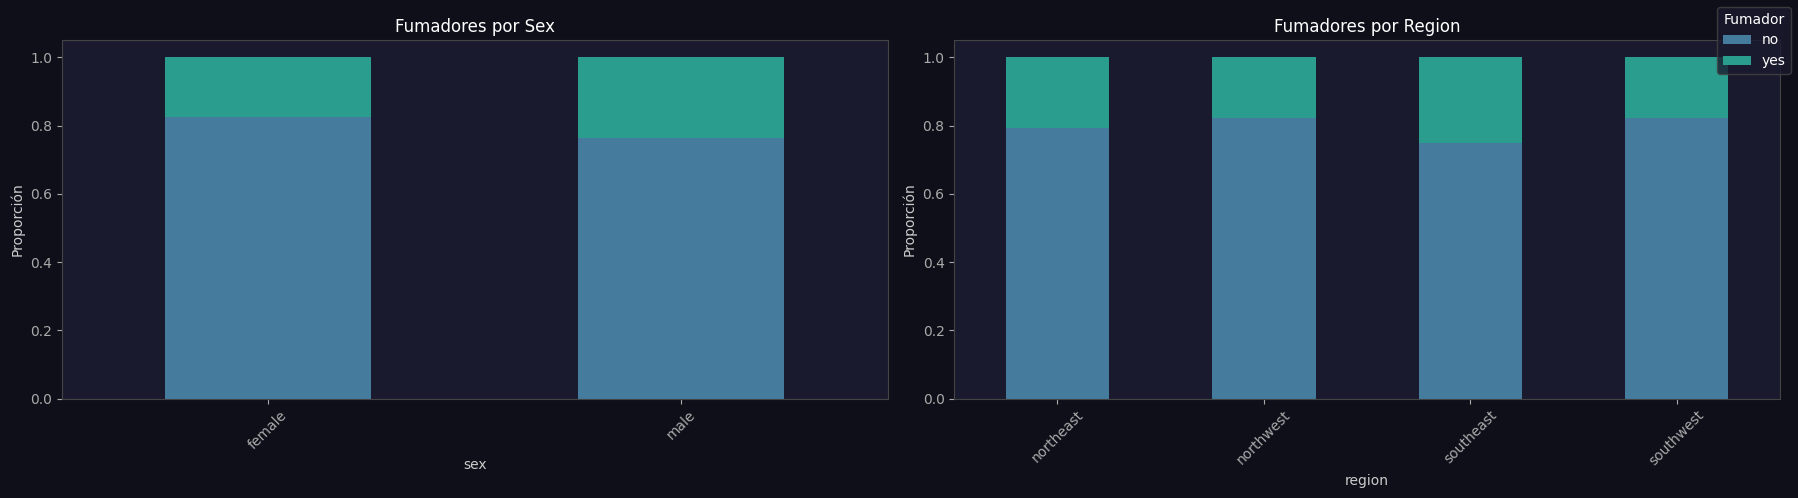

In [14]:
vars_to_plot = ['sex', 'region']
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for i, var in enumerate(vars_to_plot):
    crosstab = pd.crosstab(df[var], df['smoker'], normalize='index')
    crosstab.plot(kind='bar', stacked=True, ax=axes[i], color=['#457b9d', '#2a9d8f'])
    axes[i].set_title(f'Fumadores por {var.capitalize()}')
    axes[i].set_ylabel('Proporción')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend_.remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Fumador', loc='upper right')

plt.tight_layout()
plt.show()

>**Analisis**

`sex` Los hombres tienen una proporción de fumadores un poco mas alta (barra verde más alta) que las mujeres.

`region` casi todas sus barras son iguales (excepto por southeast que tiene una mayor proporcion de fumadores)


> ## <font color='#1890A3'>**Histogramas con KDE de variables numericas independientes**</font>

**Objetivo:** Ver la distribucion de las variables numericas independientes para determinar en el procesamiento el escalador mas adecuado.

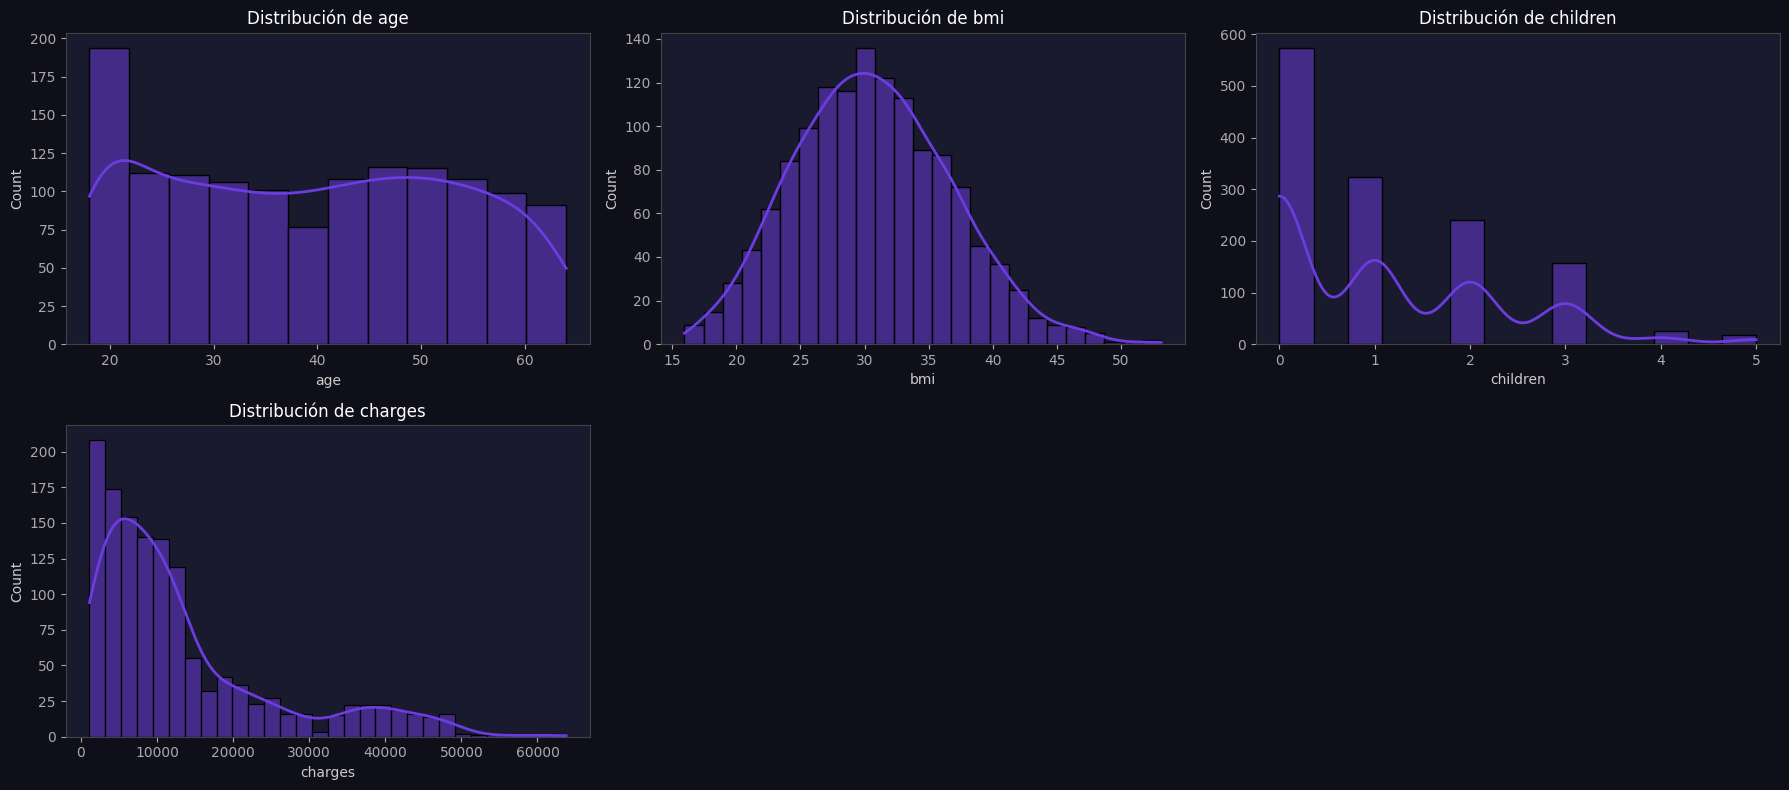

In [15]:
cols_to_exclude = ['sex', 'smoker', 'region']
cols_numeric = [col for col in df.columns if col not in cols_to_exclude]

n_cols = 3
n_rows = math.ceil(len(cols_numeric) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_numeric):
    sns.histplot(data=df, x=col, kde=True, color=PURPLE, ax=axes[i],
                 line_kws={'color': AMBER, 'linewidth': 2})
    axes[i].set_title(f'Distribución de {col}', color='white')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


>**Analisis**

- **`age`:** distribución bastante uniforme, con una ligera concentración en los adultos más jóvenes (cerca de los 20 años). El modelo tendrá una muestra representativa de todas las edades sin un sesgo marcado hacia un grupo etario específico.

- **`bmi`**: con distribucion casi normal, muy ligeramente sesgada a la derecha

- **`children`**, tiene una distribucion de cola larga sesgada a la derecha, la mayoria de las personas no tienen hijos, y la frecuencia disminuye a medida que aumenta el número de hijos.

- **`charges`**: la grafica muestra un gran numero de datos con charges oor debajo de los 15 000 usd y luego a medida que los charges aumentan los registros tambien disminuyen. Distribucion sesgada a la derecha



# <font color='#1890A3'> **SECCION 4 PREPROCESAMIENTO DE DATOS**
**Categorias|Train/Test | Escalamiento** </font>

> ### <font color='#1890A3'>**4.1 Categorizacion de Variables**</font>

Variable objetivo `smoke` a categorica binaria: fumador = 1
no fumador = 0


In [16]:
df_clean = df.copy()
df_clean['smoker_bin'] = df_clean['smoker'].map({'yes': 1, 'no': 0})
df_clean = df_clean.drop(columns=['smoker'])
print(f'Shape: {df_clean.shape}')
print(f'Distribución de smoker:\n{df_clean["smoker_bin"].value_counts()}')


Shape: (1338, 7)
Distribución de smoker:
smoker_bin
0    1064
1     274
Name: count, dtype: int64


> ## <font color='#1890A3'>**Heatmap de Correlaciones variables numéricas**</font>

**Objetivo:** Ver todas las correlaciones entre todas las variables del dataset

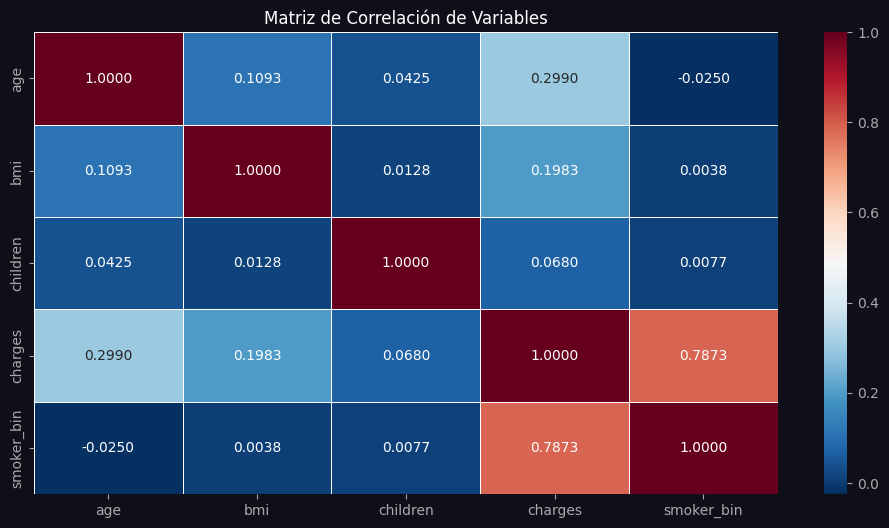

In [17]:
df_numerico = df_clean.select_dtypes(include=['float64', 'int64'])
matriz_corr = df_numerico.corr()
plt.figure(figsize=(12, 6))
sns.heatmap(matriz_corr, annot=True, cmap='RdBu_r', fmt='.4f', linewidths=0.5)

plt.title('Matriz de Correlación de Variables')
plt.show()

>**Analisis**

`smoker_bin` tiene correlacion positiva alta con `charges`(0.79), lo que indica que ser fumador es el factor mas influyente en el costo del seguro medico.

LA correlacion con `bmi` y `children` es practicamente despreciable con valores de 0.0038 y 0.0079 , es decir que estos factores no influyen en la determinacion del costo del seguro medico.

La correlacion con `age` aunque es negativa, es igualmente despreciable -0.025


> ## <font color='#1890A3'>**4.2 Split Estratificado**</font>

In [18]:
features = ['age', 'sex', 'bmi', 'children', 'region', 'charges']
X = df_clean[features].copy()
y = df_clean['smoker_bin']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'X shape: {X.shape}')
print(f'Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras')
print(f'% fumadores train: {y_train.mean()*100:.1f}% | test: {y_test.mean()*100:.1f}%')


X shape: (1338, 6)
Train: 1070 muestras | Test: 268 muestras
% fumadores train: 20.5% | test: 20.5%


> ## <font color='#1890A3'>**4.3 Column Transformer + Pipeline Diferenciado**</font>

In [21]:
cols_std = ['age', 'bmi']
cols_minmax = ['charges', 'children']
cols_cat = ['sex', 'region']

std_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

minmax_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('std', std_pipeline, cols_std),
        ('minmax', minmax_pipeline, cols_minmax),
        ('cat', cat_pipeline, cols_cat)
    ]
)

X_train_t = preprocessor.fit_transform(X_train)
X_test_t  = preprocessor.transform(X_test)

print("✅ Pipeline configurado con escaladores diferenciados segun la variable")

✅ Pipeline configurado con escaladores diferenciados segun la variable


# <font color='#1890A3'> **SECCION 5  ENTRENAMIENTO Y EVALUACION DE MODELOS**
**|Regresion Logistica | KNN | Decision Tree | RandomForest** </font>

> ## <font color='#1890A3'>**5.1 Modelado**</font>

⚠️ **Métrica de CV:** `roc_auc` (robusta ante desbalance).

In [22]:
modelos = {
    'Logistic Regression': Pipeline([
        ('pre', preprocessor),
        ('mod', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'KNN (k=11)': Pipeline([
        ('pre', preprocessor),
        ('mod', KNeighborsClassifier(n_neighbors=11))
    ]),
    'Decision Tree (d=5)': Pipeline([
        ('pre', preprocessor),
        ('mod', DecisionTreeClassifier(max_depth=5, random_state=42))
    ]),
    'Random Forest (200)': Pipeline([
        ('pre', preprocessor),
        ('mod', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
    ]),
}
print('✅Modelos creados correctamente')


✅Modelos creados correctamente


Validacion cruzada para evaluar el rendimiento inicial de los modelos, con X_train

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados_cv = {}
print('Ejecutando validación cruzada (5-fold, scoring=roc_auc)...')

for nombre, pipe in modelos.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    resultados_cv[nombre] = scores
    print(f'  {nombre:25s}  AUC-CV = {scores.mean():.4f} ± {scores.std():.4f}')

print('\n✅ Validación cruzada completada.')

Ejecutando validación cruzada (5-fold, scoring=roc_auc)...
  Logistic Regression        AUC-CV = 0.9828 ± 0.0070
  KNN (k=11)                 AUC-CV = 0.7577 ± 0.0149
  Decision Tree (d=5)        AUC-CV = 0.9716 ± 0.0124
  Random Forest (200)        AUC-CV = 0.9904 ± 0.0042

✅ Validación cruzada completada.


> ## <font color='#1890A3'>**5.2 Entrenamiento y  Evaluacion**</font>

In [24]:
resultados = []
pipes_entrenados = {}

for nombre, pipe in modelos.items():
    pipe.fit(X_train, y_train)
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    pipes_entrenados[nombre] = pipe

    resultados.append({
        'Modelo':    nombre,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
        'F1':        f1_score(y_test, y_pred, zero_division=0),
        'AUC-Test':  roc_auc_score(y_test, y_proba),
        'AUC-CV':    resultados_cv[nombre].mean()
    })

tabla_base = pd.DataFrame(resultados).set_index('Modelo') \
             .sort_values('AUC-Test', ascending=False).round(4)

print('Benchmark inicial — métricas en test:')
print(tabla_base.to_string())



Benchmark inicial — métricas en test:
                     Accuracy  Precision  Recall      F1  AUC-Test  AUC-CV
Modelo                                                                    
Random Forest (200)    0.9739     0.9138  0.9636  0.9381    0.9941  0.9904
Logistic Regression    0.9179     0.9024  0.6727  0.7708    0.9913  0.9828
Decision Tree (d=5)    0.9701     0.9608  0.8909  0.9245    0.9609  0.9716
KNN (k=11)             0.8209     0.8889  0.1455  0.2500    0.6825  0.7577


El accuracy alto puede deberse a que el modelo prediga siempre la clase con mas registros (no fumadores). El **AUC-test** indica que tan bueno es cada modelo separando clases junto al **Recall** que responde a la pregunta de negocio: "*¿Qué porcentaje de fumadores logramos detectar?*", son las metricas mas importante a evaluar.

* **Random Forest** (200) con un Recall de 0.9636 y un AUC de 0.9941 en pruebas es el modelo con  mejores metricas. Su acurracy de 0.9739 que unido al F1-score de 0.9381 y el recall de 0.9636 indican que el modelo es bueno identificando los fumadores reales y evitando los falsos negativos, asi como separando a los fumadores de los no fumadores.

* **La Regresión Logística** muestra buena capacidad predictiva, con accuracy de 0.9179 pero falla al capturar la totalidad de los casos positivos (Recall de 0.6727).

* **Decision Tree** tiene F1 ligeramente mejor ( 0.9245), pero lo logra sacrificando Recall a favor de Precision, y sabemos que la precision no es el mejor parametro por lo desbalanceado de nuestro target.

* El **KNN** es el modelo con peor desempeño (AUC-Test 0.6825, F1 0.25).


> ## <font color='#1890A3'>**5.3  Visualizacion de las metricas mas importantes en todos los modelos (Recall y AUC-test)**</font>

**Accuracy:** % de predicciones correctas (es enganosa por el desbalance del target).

**Precision:** de los que digo "fumador", ¿cuántos lo son realmente?

**Recall:** de los fumadores reales, ¿cuántos detecté?

**F1**: balance entre Precision y Recall.

**AUC-ROC:** capacidad del modelo de discriminar entre clases en todos los umbrales.

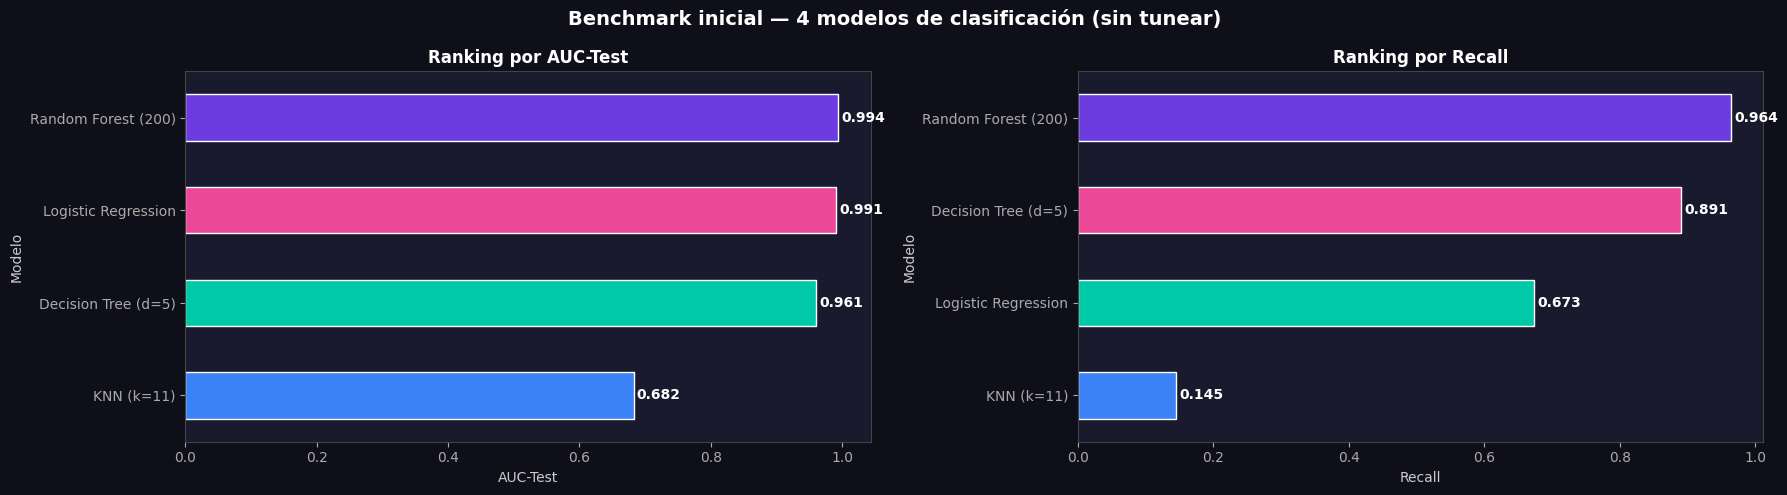


🏆 Mejor modelo sin tuning: Random Forest (200)
   AUC-Test: 0.9941
   Recall:       0.9636


In [25]:
colores = [PURPLE, PINK, TEAL, BLUE]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, metric in zip(axes, ['AUC-Test', 'Recall']):
    tabla_base[metric].sort_values().plot(
        kind='barh', ax=ax, color=colores[::-1], edgecolor='white')
    ax.set_title(f'Ranking por {metric}', fontweight='bold', fontsize=12)
    ax.set_xlabel(metric)
    for i, v in enumerate(tabla_base[metric].sort_values()):
        ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontweight='bold')

plt.suptitle('Benchmark inicial — 4 modelos de clasificación (sin tunear)',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()
ganador_base = tabla_base['AUC-Test'].idxmax()
print(f'\n🏆 Mejor modelo sin tuning: {ganador_base}')
print(f'   AUC-Test: {tabla_base.loc[ganador_base, "AUC-Test"]:.4f}')
print(f'   Recall:       {tabla_base.loc[ganador_base, "Recall"]:.4f}')



>**Analisis**

Los gráficos confirman que el Random Forest es el modelo más robusto  ya que lidera consistentemente tanto en capacidad de discriminar a los fumadores de los no fumadores (AUC-Test de 0.9941) como en la capacidad de detección de fumadores (Recall de 0.9636).

La Regresión Logística muestra una capacidad de separación competitiva (AUC de 0.991), pero su Recall es mas bajo (891), es decir su capacidad de identificar casos positivos.

El Decision Tree tiene un desempeño aceptable, con AUC-test de 0.961 y Recall de 0.673, falla mas al identificar los casos positivos (fumadores).

KNN resulta claramente con las metricas mas bajas, al tener el peor desempeno en la detección de fumadores (Recall de 0.145).

# <font color='#1890A3'> **SECCION 6  OPTIMIZACION DE HIPERPARAMETROS**
**|GridSearchCV | RandomizedSearchCV |** </font>

> ## <font color='#1890A3'>**6.1  GridSearchCV** </font>
Se aplicara a RandomForest, Decision Tree y Regresion Logistica.
Usare `scoring = 'F1'` porque hay desbalance de clase

In [27]:
configuraciones = {
    'Decision Tree': {
        'pipe': Pipeline([
            ('pre', preprocessor),
            ('mod', DecisionTreeClassifier(random_state=42))
        ]),
        'params': {
            'mod__max_depth':        [3, 5, 10, 15],
            'mod__min_samples_leaf': [1, 5, 10],
            'mod__criterion':        ['gini', 'entropy']
        }
    },
    'Random Forest': {
        'pipe': Pipeline([
            ('pre', preprocessor),
            ('mod', RandomForestClassifier(random_state=42, n_jobs=-1))
        ]),
        'params': {
            'mod__n_estimators':     [200, 500],
            'mod__max_depth':        [5, 10, 20, None],
            'mod__min_samples_leaf': [1, 3, 5]
        }
    },
     'KNN': {
        'pipe': Pipeline([
            ('pre', preprocessor),
            ('mod', KNeighborsClassifier())
        ]),
        'params': {
            'mod__n_neighbors': [3, 5, 7, 11, 15, 21, 31],
            'mod__weights':     ['uniform', 'distance'],
            'mod__metric':      ['euclidean', 'manhattan']
        }
     },
    'Logistic Regression': {
        'pipe': Pipeline([
            ('pre', preprocessor),
            ('mod', LogisticRegression(max_iter=1000, random_state=42))
        ]),
        'params': {
            'mod__C':       [0.01, 0.1, 1.0, 10.0],
            'mod__penalty': ['l1', 'l2'],
            'mod__solver':  ['saga']
        }
    }
}

resultados_grid = {}

for nombre, config in configuraciones.items():
    print(f'=== GridSearchCV — {nombre} ===')
    grid = GridSearchCV(
        config['pipe'], config['params'],
        scoring='f1', cv=cv,
        n_jobs=-1, verbose=0
    )
    grid.fit(X_train, y_train)
    resultados_grid[f'Grid — {nombre}'] = grid
    print(f'  Mejor F1 en CV: {grid.best_score_:.4f}')
    print(f'  Mejores parámetros: {grid.best_params_}\n')

print('✅ GridSearchCV completado.')

filas_grid = []
for nombre, grid in resultados_grid.items():
    y_pred  = grid.predict(X_test)
    y_proba = grid.predict_proba(X_test)[:, 1]
    filas_grid.append({
        'Modelo':    nombre,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
        'F1':        f1_score(y_test, y_pred, zero_division=0),
        'AUC':       roc_auc_score(y_test, y_proba)
    })

tabla_grid = pd.DataFrame(filas_grid).set_index('Modelo').round(4)
print(tabla_grid.to_string())

=== GridSearchCV — Decision Tree ===
  Mejor F1 en CV: 0.9100
  Mejores parámetros: {'mod__criterion': 'entropy', 'mod__max_depth': 3, 'mod__min_samples_leaf': 10}

=== GridSearchCV — Random Forest ===
  Mejor F1 en CV: 0.8928
  Mejores parámetros: {'mod__max_depth': 20, 'mod__min_samples_leaf': 1, 'mod__n_estimators': 200}

=== GridSearchCV — KNN ===
  Mejor F1 en CV: 0.6296
  Mejores parámetros: {'mod__metric': 'manhattan', 'mod__n_neighbors': 3, 'mod__weights': 'distance'}

=== GridSearchCV — Logistic Regression ===
  Mejor F1 en CV: 0.8645
  Mejores parámetros: {'mod__C': 10.0, 'mod__penalty': 'l1', 'mod__solver': 'saga'}

✅ GridSearchCV completado.
                            Accuracy  Precision  Recall      F1     AUC
Modelo                                                                 
Grid — Decision Tree          0.9701     0.9123  0.9455  0.9286  0.9747
Grid — Random Forest          0.9739     0.9138  0.9636  0.9381  0.9941
Grid — KNN                    0.8545     0.7857  0

**Random Forest:** Obtuvo un F1 de 0.9381 y Recall de 0.9636, posicionandose como el mejor modelo tras el ajuste.

**Decision Tree:** Con un F1 de 0.926, y Recall de 0.9455 el Árbol de Decisión tiene un desempeno ligeramente inferior a RandomForest.


**Logistic Regression:** Con un F1 de 0.9286 y Recall de 0.9455, se mantiene como un modelo de referencia sólido, ligeramente inferior que RandomForest y casi igual que DecisionTree.

**KNN** Es el menos afectado por la optimizacion, obteniendo un Recall de 0.40 (falla mucho detectando a los fumadores) y F1 de 0.5301.

> ## <font color='#1890A3'>**6.2  RandomizedSearchCV** </font>
Se aplicara a RandomForest, Decision Tree y Regresion Logistica.


In [28]:
from scipy.stats import loguniform

busquedas = {
    'Decision Tree': {
        'pipe': Pipeline([
            ('pre', preprocessor),
            ('mod', DecisionTreeClassifier(random_state=42))
        ]),
        'params': {
            'mod__max_depth':        randint(3, 20),
            'mod__min_samples_leaf': randint(1, 30),
            'mod__criterion':        ['gini', 'entropy']
        }
    },
    'Random Forest': {
        'pipe': Pipeline([
            ('pre', preprocessor),
            ('mod', RandomForestClassifier(random_state=42, n_jobs=-1))
        ]),
        'params': {
            'mod__n_estimators':     randint(100, 600),
            'mod__max_depth':        [None] + list(range(5, 25)),
            'mod__min_samples_leaf': randint(1, 10),
            'mod__max_features':     ['sqrt', 'log2']
        }
    },
    'Logistic Regression': {
        'pipe': Pipeline([
            ('pre', preprocessor),
            ('mod', LogisticRegression(max_iter=1000, random_state=42))
        ]),
        'params': {
            'mod__C':       loguniform(0.001, 100),
            'mod__penalty': ['l1', 'l2'],
            'mod__solver':  ['saga']
        }
    },
      'KNN': {
        'pipe': Pipeline([
            ('pre', preprocessor),
            ('mod', KNeighborsClassifier())
        ]),
        'params': {
            'mod__n_neighbors': randint(3, 35),
            'mod__weights':     ['uniform', 'distance'],
            'mod__metric':      ['euclidean', 'manhattan']
        }
    }
}

resultados_random = {}

for nombre, config in busquedas.items():
    print(f'=== RandomizedSearchCV — {nombre} ===')
    rand = RandomizedSearchCV(
        config['pipe'],
        config['params'],
        n_iter=30,
        scoring='f1',
        cv=cv,
        n_jobs=-1,
        random_state=42,
        verbose=0
    )
    rand.fit(X_train, y_train)
    resultados_random[f'Random — {nombre}'] = rand
    print(f'  Mejor F1 en CV: {rand.best_score_:.4f}')
    print(f'  Mejores parámetros: {rand.best_params_}\n')

print('✅ RandomizedSearchCV completado.')

filas_random = []

for nombre, rand in resultados_random.items():
    y_pred  = rand.predict(X_test)
    y_proba = rand.predict_proba(X_test)[:, 1]
    filas_random.append({
        'Modelo':    nombre,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
        'F1':        f1_score(y_test, y_pred, zero_division=0),
        'AUC':       roc_auc_score(y_test, y_proba)
    })

tabla_random = pd.DataFrame(filas_random).set_index('Modelo').round(4)
print(tabla_random.to_string())

=== RandomizedSearchCV — Decision Tree ===
  Mejor F1 en CV: 0.9100
  Mejores parámetros: {'mod__criterion': 'entropy', 'mod__max_depth': 3, 'mod__min_samples_leaf': 12}

=== RandomizedSearchCV — Random Forest ===
  Mejor F1 en CV: 0.8913
  Mejores parámetros: {'mod__max_depth': 10, 'mod__max_features': 'log2', 'mod__min_samples_leaf': 8, 'mod__n_estimators': 288}

=== RandomizedSearchCV — Logistic Regression ===
  Mejor F1 en CV: 0.8648
  Mejores parámetros: {'mod__C': np.float64(0.9846738873614566), 'mod__penalty': 'l1', 'mod__solver': 'saga'}

=== RandomizedSearchCV — KNN ===
  Mejor F1 en CV: 0.5877
  Mejores parámetros: {'mod__metric': 'manhattan', 'mod__n_neighbors': 5, 'mod__weights': 'distance'}

✅ RandomizedSearchCV completado.
                              Accuracy  Precision  Recall      F1     AUC
Modelo                                                                   
Random — Decision Tree          0.9701     0.9123  0.9455  0.9286  0.9747
Random — Random Forest         

**Decision Tree**  F1 en 0.9286 y Recall 0.9455 con los mismos valores que **RandomForest** solo el AUC de RandomForest ligeramente superior 0.9930 vs 0.9747.

**Regresion Logistica** con 0.9091 en sus principales metricas se mantiene como un competidor sólido, con un ligera caída respecto al Árbol de Decisión y RandomForest

 **KNN** La optimizacon no logro mejorar mucho sus parametros, F1 con 0.5 y Recall de 0.36336 lo mantienen como el modelo con menor rendimiento


> ## <font color='#1890A3'>**6.2  GridSearchCV vs RandomizedSearchCV** </font>


In [29]:
filas_comparativa = []

for nombre, grid in resultados_grid.items():
    y_pred  = grid.predict(X_test)
    y_proba = grid.predict_proba(X_test)[:, 1]
    filas_comparativa.append({
        'Estrategia': 'GridSearch',
        'Modelo':     nombre.replace('Grid — ', ''),
        'Accuracy':   accuracy_score(y_test, y_pred),
        'Precision':  precision_score(y_test, y_pred, zero_division=0),
        'Recall':     recall_score(y_test, y_pred, zero_division=0),
        'F1':         f1_score(y_test, y_pred, zero_division=0),
        'AUC':        roc_auc_score(y_test, y_proba)
    })

for nombre, rand in resultados_random.items():
    y_pred  = rand.predict(X_test)
    y_proba = rand.predict_proba(X_test)[:, 1]
    filas_comparativa.append({
        'Estrategia': 'RandomSearch',
        'Modelo':     nombre.replace('Random — ', ''),
        'Accuracy':   accuracy_score(y_test, y_pred),
        'Precision':  precision_score(y_test, y_pred, zero_division=0),
        'Recall':     recall_score(y_test, y_pred, zero_division=0),
        'F1':         f1_score(y_test, y_pred, zero_division=0),
        'AUC':        roc_auc_score(y_test, y_proba)
    })

tabla_comparativa = (
    pd.DataFrame(filas_comparativa)
    .set_index(['Estrategia', 'Modelo'])
    .sort_values(['Estrategia', 'AUC'], ascending=[True, False])
    .round(4)
)

print('Tabla comparativa — GridSearch vs RandomizedSearch')
print(tabla_comparativa.to_string())

idx_ganador = tabla_comparativa['AUC'].idxmax()
f1_gan      = tabla_comparativa.loc[idx_ganador, 'F1']
auc_gan     = tabla_comparativa.loc[idx_ganador, 'AUC']
recall_gan  = tabla_comparativa.loc[idx_ganador, 'Recall']

print(f'\n🏆 Mejor modelo global: {idx_ganador[0]} — {idx_ganador[1]}')
print(f'   AUC    = {auc_gan:.4f}')
print(f'   F1     = {f1_gan:.4f}')
print(f'   Recall = {recall_gan:.4f}')



Tabla comparativa — GridSearch vs RandomizedSearch
                                  Accuracy  Precision  Recall      F1     AUC
Estrategia   Modelo                                                          
GridSearch   Random Forest          0.9739     0.9138  0.9636  0.9381  0.9941
             Logistic Regression    0.9701     0.9123  0.9455  0.9286  0.9927
             Decision Tree          0.9701     0.9123  0.9455  0.9286  0.9747
             KNN                    0.8545     0.7857  0.4000  0.5301  0.8325
RandomSearch Random Forest          0.9701     0.9123  0.9455  0.9286  0.9930
             Logistic Regression    0.9627     0.9091  0.9091  0.9091  0.9925
             Decision Tree          0.9701     0.9123  0.9455  0.9286  0.9747
             KNN                    0.8507     0.8000  0.3636  0.5000  0.8314

🏆 Mejor modelo global: GridSearch — Random Forest
   AUC    = 0.9941
   F1     = 0.9381
   Recall = 0.9636


### <font color='#1890A3'>**BArPlot GridSearchCV vs RandomizedSearchCV por Modelo y Metrica** </font>

In [30]:
df_plot = tabla_comparativa.reset_index()

metricas   = ['AUC', 'F1', 'Recall', 'Precision']
estrategia = ['GridSearch', 'RandomSearch']
colores    = {'GridSearch': TEAL, 'RandomSearch': PURPLE}
titulos    = {
    'AUC':       'AUC — discriminación global',
    'F1':        'F1 — balance Precision/Recall',
    'Recall':    'Recall — detección de fumadores',
    'Precision': 'Precision — calidad de alertas'
}
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=list(titulos.values()),
    vertical_spacing=0.18,
    horizontal_spacing=0.10
)
posiciones = [(1,1), (1,2), (2,1), (2,2)]
for (row, col), metrica in zip(posiciones, metricas):
    for est in estrategia:
        subset = df_plot[df_plot['Estrategia'] == est].sort_values('Modelo')
        fig.add_trace(
            go.Bar(
                name=est,
                x=subset['Modelo'],
                y=subset[metrica],
                marker_color=colores[est],
                text=subset[metrica].round(3),
                textposition='outside',
                textfont=dict(size=10),
                showlegend=(row == 1 and col == 1),
                legendgroup=est
            ),
            row=row, col=col
        )

    media = df_plot[metrica].mean()
    fig.add_hline(
        y=media, row=row, col=col,
        line_dash='dot', line_color='white',
        line_width=1, opacity=0.4,
        annotation_text=f'  media {media:.2f}',
        annotation_font_size=10,
        annotation_font_color='white'
    )
fig.update_layout(
    **template['layout'],
    title=dict(
        text='<b>GridSearch vs RandomizedSearch — Comparativa de Metricas</b>',
        font=dict(size=16)
    ),
    barmode='group',
    height=650,
    legend=dict(
        orientation='h',
        yanchor='bottom', y=1.04,
        xanchor='center', x=0.5,
        font=dict(size=12)
    ),
    margin=dict(t=100, b=60, l=60, r=40)
)
for (row, col), metrica in zip(posiciones, metricas):
    ymin = max(0, df_plot[metrica].min() - 0.05)
    ymax = min(1, df_plot[metrica].max() + 0.07)
    fig.update_yaxes(range=[ymin, ymax], row=row, col=col)

fig.show()

>**Analisis**

*KNN** tiene metricas muy por debajo del resto de los modelos con cualquiera de las estrategias de optimizacion.

Para el resto de los modelos las metricas son practicamente las mismas con las dos optimizaciones, aunque las de **Decision Tree** esten ligeramente mas bajas todas estan en un rango superior a 0.91.Estos modelos llegaron al techo de su rendimiento



# <font color='#1890A3'> **SECCION 7 EVALUACION FINAL DE MODELOS OPTIMIZADOS**
 </font>

> ## <font color='#1890A3'>**7.1 Evaluacion con Test** </font>
selecciono el mejor modelo considerando mayor F1 en CV

In [31]:
def mejor_entre(nombre_modelo):
    clave_grid   = f'Grid — {nombre_modelo}'
    clave_random = f'Random — {nombre_modelo}'
    opciones = {}
    if clave_grid   in resultados_grid:   opciones[clave_grid]   = resultados_grid[clave_grid]
    if clave_random in resultados_random: opciones[clave_random] = resultados_random[clave_random]
    return max(opciones.items(), key=lambda x: x[1].best_score_)

nombre_lr,  search_lr  = mejor_entre('Logistic Regression')
nombre_dt,  search_dt  = mejor_entre('Decision Tree')
nombre_rf,  search_rf  = mejor_entre('Random Forest')
nombre_knn, search_knn = mejor_entre('KNN')

print('Modelos seleccionados para evaluación final:')
print(f'  Logistic Regression → {nombre_lr}  (F1-CV: {search_lr.best_score_:.4f})')
print(f'  Decision Tree       → {nombre_dt}  (F1-CV: {search_dt.best_score_:.4f})')
print(f'  Random Forest       → {nombre_rf}  (F1-CV: {search_rf.best_score_:.4f})')
print(f'  KNN                 → {nombre_knn} (F1-CV: {search_knn.best_score_:.4f})')

modelos_optimizados = {
    'Logistic Regression': search_lr.best_estimator_,
    'Decision Tree':       search_dt.best_estimator_,
    'Random Forest':       search_rf.best_estimator_,
    'KNN':                 search_knn.best_estimator_,
}

tabla_final = []
for nombre, modelo in modelos_optimizados.items():
    y_pred  = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    tabla_final.append({
        'Modelo':    nombre,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
        'F1':        f1_score(y_test, y_pred, zero_division=0),
        'AUC':       roc_auc_score(y_test, y_proba)
    })

df_final = (pd.DataFrame(tabla_final)
              .set_index('Modelo')
              .sort_values('AUC', ascending=False)
              .round(4))

print('\nEvaluación final — Modelos optimizados en test:')
print(df_final.to_string())

top_nombre  = df_final['AUC'].idxmax()
top_modelo  = modelos_optimizados[top_nombre]
y_pred_top  = top_modelo.predict(X_test)

print(f'\n=== Classification Report — {top_nombre} (Ganador) ===')
print(classification_report(y_test, y_pred_top,
                             target_names=['No fumador (0)', 'Fumador (1)']))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_top).ravel()
print(f'Análisis de errores — {top_nombre}:')
print(f'  TP = {tp}  fumadores detectados correctamente      ✅')
print(f'  TN = {tn}  no fumadores detectados correctamente   ✅')
print(f'  FP = {fp}  no fumadores clasificados como fumadores ⚠️')
print(f'  FN = {fn}  fumadores no detectados (error crítico)  ❌')
print(f'\n  Recall clase Fumador: {tp/(tp+fn):.1%} — detectamos {tp} de {tp+fn} fumadores reales')
print(f'  Un FN = aseguradora cobra prima de no-fumador → pérdida directa')

Modelos seleccionados para evaluación final:
  Logistic Regression → Random — Logistic Regression  (F1-CV: 0.8648)
  Decision Tree       → Grid — Decision Tree  (F1-CV: 0.9100)
  Random Forest       → Grid — Random Forest  (F1-CV: 0.8928)
  KNN                 → Grid — KNN (F1-CV: 0.6296)

Evaluación final — Modelos optimizados en test:
                     Accuracy  Precision  Recall      F1     AUC
Modelo                                                          
Random Forest          0.9739     0.9138  0.9636  0.9381  0.9941
Logistic Regression    0.9627     0.9091  0.9091  0.9091  0.9925
Decision Tree          0.9701     0.9123  0.9455  0.9286  0.9747
KNN                    0.8545     0.7857  0.4000  0.5301  0.8325

=== Classification Report — Random Forest (Ganador) ===
                precision    recall  f1-score   support

No fumador (0)       0.99      0.98      0.98       213
   Fumador (1)       0.91      0.96      0.94        55

      accuracy                           0.9

Con Test, RandomForest, LogisticRegression y DecisionTRee tienen metricas muy parecidas, aunque las de **Random Forest** son ligeramente superiores. Los tres modelos detectan bien quien pertenece a cada clase (fumadores y no fumadores) y detectan la mayoria de casos positivos.


> ## <font color='#1890A3'>**7.2 Matrices de Confusion** </font>

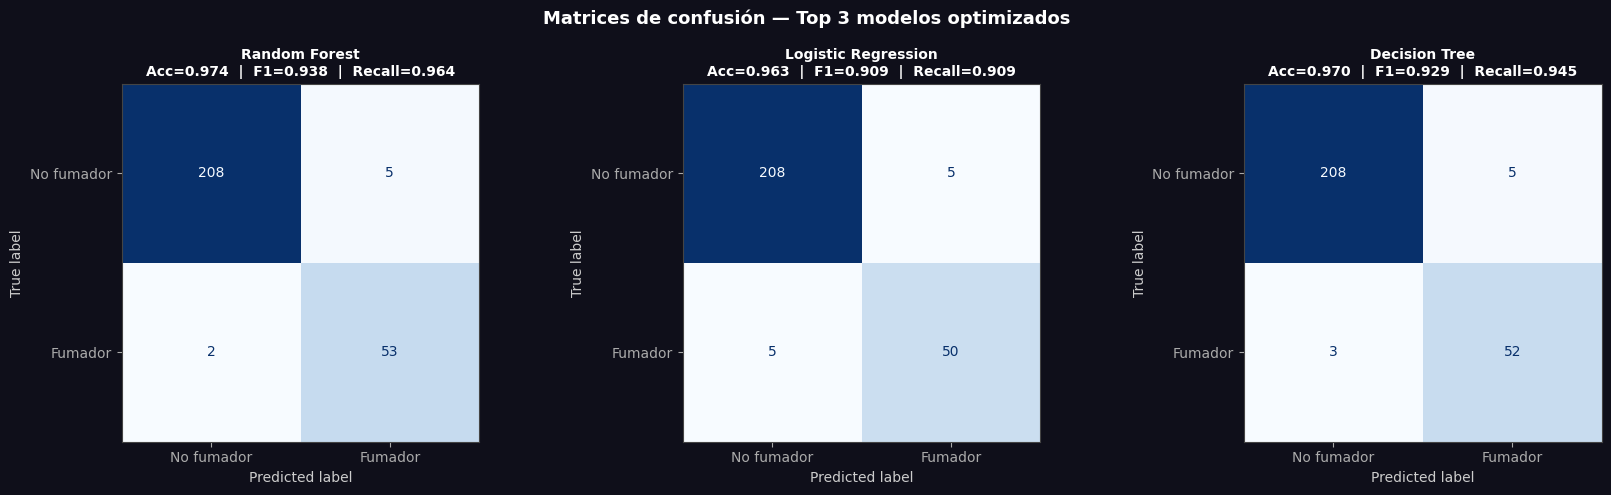

=== Análisis de errores — Random Forest ===

  TP =  53  fumadores detectados correctamente       ✅
  TN = 208  no fumadores detectados correctamente    ✅
  FP =   5  no fumadores clasificados como fumadores  ⚠️  falso positivo
  FN =   2  fumadores no detectados                   ❌  falso negativo

  Tasa de error clase Fumador    (FN): 2/55 = 3.6%
  Tasa de error clase No Fumador (FP): 5/213 = 2.3%

  Recall = 53/55 = 96.4% → detectamos 53 de 55 fumadores reales


In [33]:
top3 = df_final['AUC'].sort_values(ascending=False).head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, nombre in zip(axes, top3):
    y_pred = modelos_optimizados[nombre].predict(X_test)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=ax,
        cmap='Blues',
        display_labels=['No fumador', 'Fumador'],
        colorbar=False
    )
    acc    = accuracy_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    ax.set_title(
        f'{nombre}\nAcc={acc:.3f}  |  F1={f1:.3f}  |  Recall={recall:.3f}',
        fontweight='bold', fontsize=10
    )

plt.suptitle(
    'Matrices de confusión — Top 3 modelos optimizados',
    fontweight='bold', fontsize=13
)
plt.tight_layout()
plt.show()

y_pred_gan = modelos_optimizados[top_nombre].predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_gan).ravel()

total_fumadores     = tp + fn
total_no_fumadores  = tn + fp

print(f'=== Análisis de errores — {top_nombre} ===\n')
print(f'  TP = {tp:>3}  fumadores detectados correctamente       ✅')
print(f'  TN = {tn:>3}  no fumadores detectados correctamente    ✅')
print(f'  FP = {fp:>3}  no fumadores clasificados como fumadores  ⚠️  falso positivo')
print(f'  FN = {fn:>3}  fumadores no detectados                   ❌  falso negativo')
print(f'\n  Tasa de error clase Fumador    (FN): {fn}/{total_fumadores} = {fn/total_fumadores:.1%}')
print(f'  Tasa de error clase No Fumador (FP): {fp}/{total_no_fumadores} = {fp/total_no_fumadores:.1%}')
print(f'\n  Recall = {tp}/{total_fumadores} = {tp/total_fumadores:.1%} → detectamos {tp} de {total_fumadores} fumadores reales')


>**Analisis**

La **Regresión Logística** identifica correctamente a 52 de los 55 casos reales (solo 3 falsos negativos). Tiene una tasa baja de falsos positivos (5). Es el modelo cn mejores metricas y mas rendimiento.

**Decision Tree** y **RandomForest** identifican igualmente a los no fumadores reales y generan los mismos falsos positivos, pero DecisionTree genera menos falsos positivos mientras que LogisticRegression detecta mas fumadores reales


Los tres modelos con resultados tan similares son un indicativo de que se ha llegado al techo de optimizacion de parametros y todos los modelos convergen al mismo valor.

La decision de que modelo implementar en produccion debe considerar, tiempos y costos, y no solo las metricas.



> ## <font color='#1890A3'>**7.3 Curvas ROC**</font>

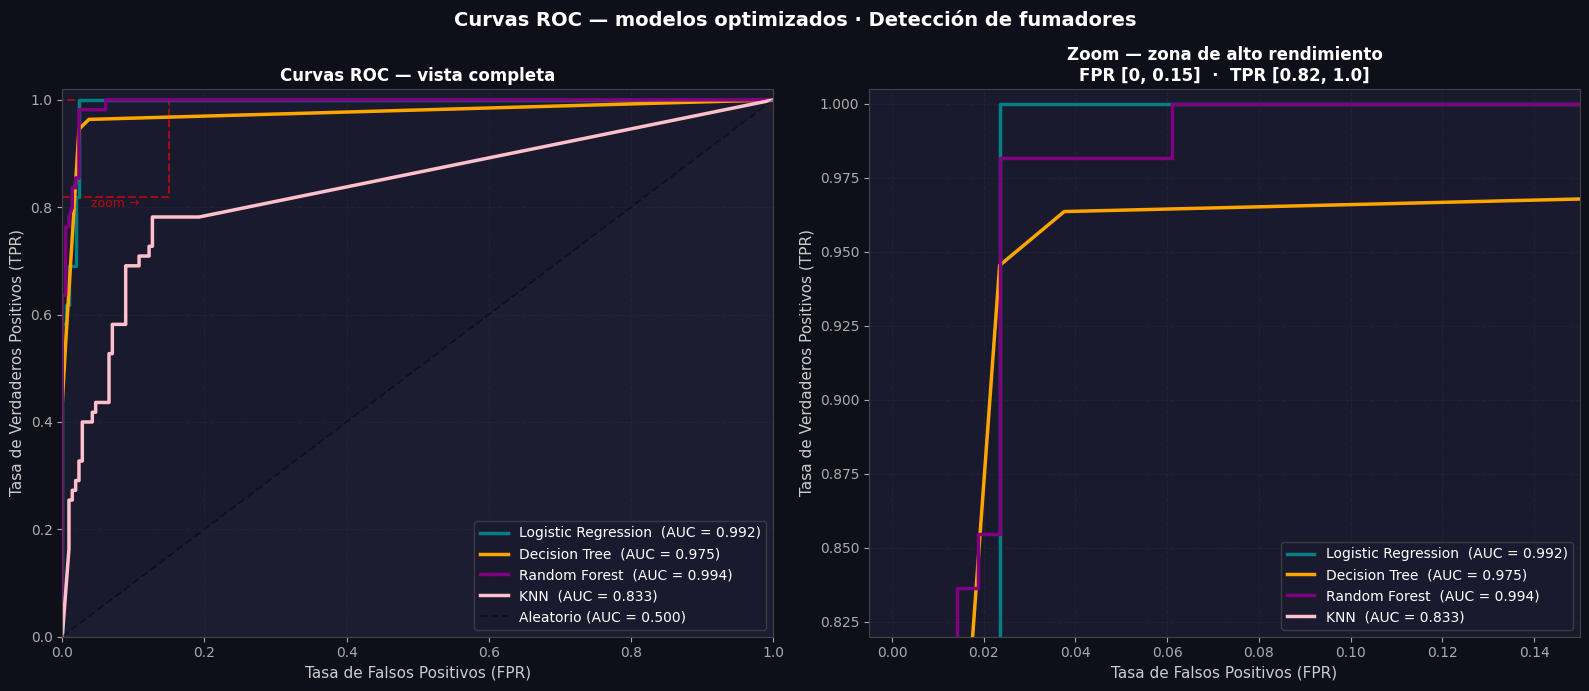

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

datos_roc = {}
for nombre, modelo in modelos_optimizados.items():
    y_proba = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    datos_roc[nombre] = (fpr, tpr, thresholds, auc_val)

for ax_idx, ax in enumerate(axes):
    for nombre, (fpr, tpr, _, auc_val) in datos_roc.items():
        ax.plot(fpr, tpr,
                label=f'{nombre}  (AUC = {auc_val:.3f})',
                linewidth=2.5,
                color=colores_roc.get(nombre, 'gray'))
    if ax_idx == 0:
        ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5,
                alpha=0.4, label='Aleatorio (AUC = 0.500)')
        ax.fill_between([0, 1], [0, 1], alpha=0.04, color='gray')
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1.02])
        ax.set_title('Curvas ROC — vista completa', fontweight='bold')
    else:
        ax.set_xlim([-0.005, 0.15])
        ax.set_ylim([0.82, 1.005])
        ax.set_title('Zoom — zona de alto rendimiento\n'
                     'FPR [0, 0.15]  ·  TPR [0.82, 1.0]',
                     fontweight='bold')
        axes[0].add_patch(Rectangle(
            (0, 0.82), 0.15, 0.18,
            fill=False, edgecolor='red',
            linewidth=1.5, linestyle='--', alpha=0.6
        ))
        axes[0].text(0.075, 0.80, 'zoom →',
                     ha='center', fontsize=9, color='red', alpha=0.7)

    ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
    ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Curvas ROC — modelos optimizados · Detección de fumadores',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

>**Analisis**

Basado en las curvas ROC presentadas para la detección de fumadores, los resultados muestran que todos los modelos evaluados presentan un desempeño excelente y similar, destacándose ligeramente Logistic Regression con el valor más alto de AUC (0.992), seguido muy de cerca por el Decision Tree (AUC = 0.975), lo cual indica una alta capacidad de discriminación entre las clases fumadores y no fumadores de ambos modelos.



## **Informe ejecutivo**

## Modelo elegido:**Random Forest Classifier (tuneado)**

Se evaluaron 4 algoritmos de clasificación (KNN, Decision Tree, Random Forest y Regresión Logística). **Random Forest fue el ganador en F1 y AUC**, sin embargo **DecisionTree** y **LogisticRegresion** generan resultados igual de optimos.

La Regresión Logística o un Decision Tree son mas faciles de interpretar y mantener que RandomForest.

---

## Métricas finales (modelo tuneado en el test set)

| Métrica | Base (Default) | Tuneado (GridSearch) |
| :--- | :---: | :---: |
| **Accuracy** | 0.9739 | 0.9739 |
| **Precision** | 0.9138 | 0.9138 |
| **Recall** | 0.9636 | 0.9636 |
| **F1 Score** | 0.93881 | 0.9381 |
| **AUC** | 0.9941 | 0.9941 |

---

## Hallazgos del análisis

1. **`charges` es el predictor número uno** Los fumadores generan costos médicos mayores.

2. **El desbalance 20/80 obliga al uso de F1 y AUC.** Un modelo naive que siempre predice "no fumador" tendría 79.5% de accuracy pero F1=0 y AUC=0.5, completamente inútil.

3. **GridSearchCV vs RandomizedSearchCV:** con este dataset (1,338 registros) ambos convergen a resultados similares. En datasets de millones de filas o grids de miles de combinaciones, podrian obtenerse resultados diferentes.

4. **El modelo no reemplaza al suscriptor médico.** Funciona como filtro de pre-screening: casos con probabilidad > umbral pasan a verificación adicional (historial médico, declaración jurada). El umbral óptimo depende del costo de negocio de cada tipo de error.

## Limitaciones del Modelo

- Solo 1,338 registros: el modelo puede ser frágil ante variaciones de la distribución de datos.
- `charges` puede ser proxy del hábito (la aseguradora ya sabe quién fuma), lo que introduce data leakage conceptual en un escenario real.
